Dataset Source: UCI Machine Learning Repository

Dataset Link: https://archive.ics.uci.edu/dataset/222/bank+marketing

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("/content/bank-full.csv",sep=';')

In [5]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


### Insight

The dataset contains 45,211 records and 17 columns. There are 7 numerical features and 10 categorical features, along with the target variable 'y'. All columns contain 45,211 non-null values, indicating that there are no missing values detected at this stage.


In [7]:
df.duplicated().sum()

np.int64(0)

The dataset contains 0 duplicate rows. This means that there are no completely identical records, so no duplicate rows need to be removed during the data cleaning process.


In [8]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


In [9]:
df['y'].value_counts(normalize=True) * 100

,proportion
y,
no,88.30152
yes,11.69848


The target variable y contains two classes: 'no' and 'yes'. There are 39,922 clients who did not subscribe to a term deposit, while 5,289 clients subscribed. This represents approximately 88.30% no and 11.70% yes. Therefore, the target variable is highly imbalanced, which should be considered when training and evaluating the classification models.


In [10]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [11]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].unique())
    print()

job: 12 unique values
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital: 3 unique values
['married' 'single' 'divorced']

education: 4 unique values
['tertiary' 'secondary' 'unknown' 'primary']

default: 2 unique values
['no' 'yes']

housing: 2 unique values
['yes' 'no']

loan: 2 unique values
['no' 'yes']

contact: 3 unique values
['unknown' 'cellular' 'telephone']

month: 12 unique values
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome: 4 unique values
['unknown' 'failure' 'other' 'success']

y: 2 unique values
['no' 'yes']



In [12]:
for col in categorical_cols:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} unknown values ({unknown_count / len(df) * 100:.2f}%)")

job: 288 unknown values (0.64%)
education: 1857 unknown values (4.11%)
contact: 13020 unknown values (28.80%)
poutcome: 36959 unknown values (81.75%)


The dataset has no actual missing values, but some categorical columns contain 'unknown'. 'job' has very few unknown values (0.64%), while 'contact' (28.80%) and 'poutcome' (81.75%) have many. These values will be retained as categories during preprocessing.


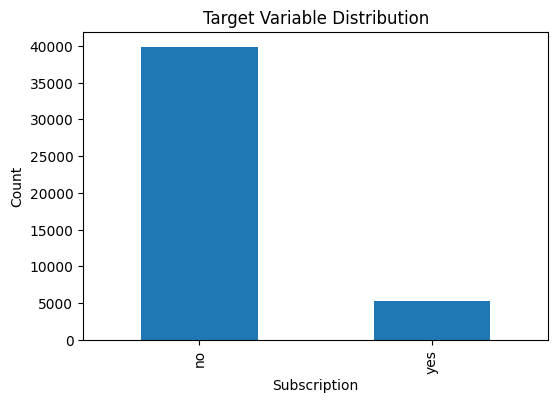

In [13]:
import matplotlib.pyplot as plt

df['y'].value_counts().plot(kind='bar', figsize=(6, 4))

plt.title('Target Variable Distribution')
plt.xlabel('Subscription')
plt.ylabel('Count')
plt.show()

The target variable is highly imbalanced, with no representing most of the records and yes representing a much smaller portion. Therefore, accuracy alone may not be sufficient for evaluating the classification models.


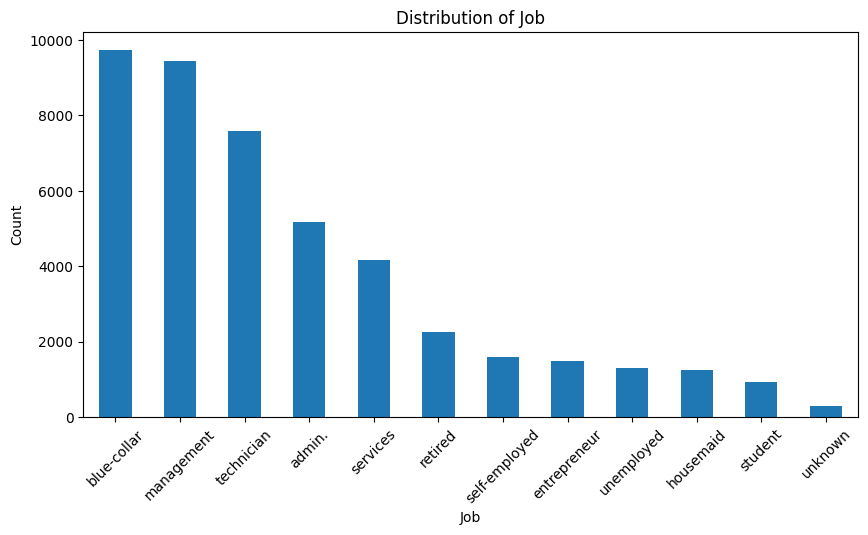

In [14]:
plt.figure(figsize=(10, 5))

df['job'].value_counts().plot(kind='bar')

plt.title('Distribution of Job')
plt.xlabel('Job')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

The dataset is mainly composed of blue-collar, management, and technician workers, while groups such as students, housemaids, and unemployed clients are smaller. The unknown category is very small, so it is retained as a separate category during preprocessing.

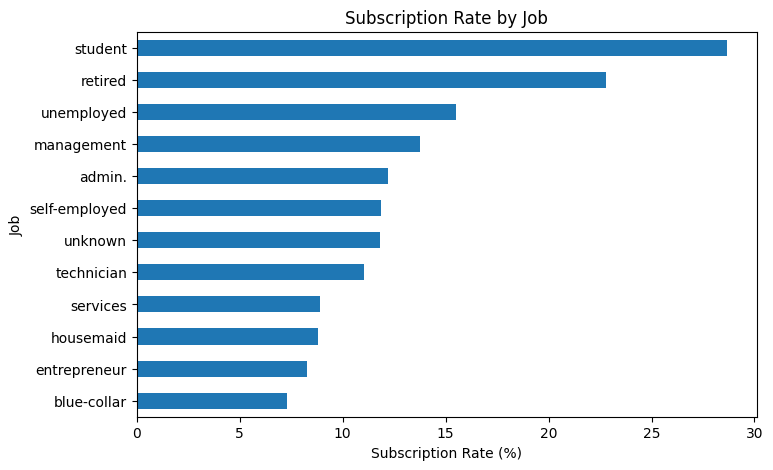

In [15]:
job_subscription = pd.crosstab(df['job'], df['y'], normalize='index') * 100

job_subscription['yes'].sort_values().plot(
    kind='barh',
    figsize=(8, 5)
)

plt.title('Subscription Rate by Job')
plt.xlabel('Subscription Rate (%)')
plt.ylabel('Job')
plt.show()

Subscription rates vary across job categories. Students and retired clients have the highest subscription rates, while blue-collar, entrepreneur, housemaid, and services have lower rates. However, smaller groups should be interpreted carefully because they contain fewer clients.

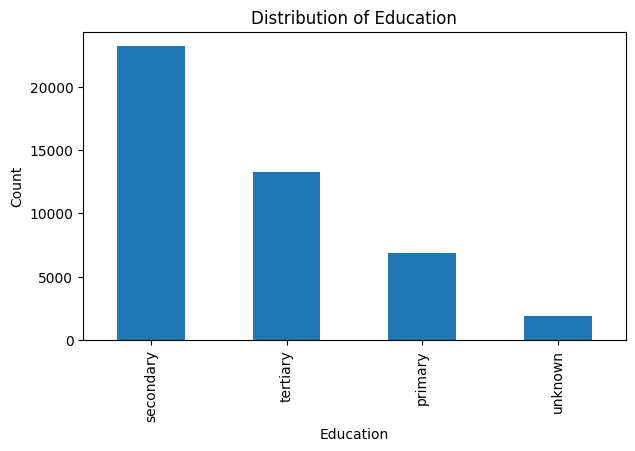

In [16]:
df['education'].value_counts().plot(
    kind='bar',
    figsize=(7, 4)
)

plt.title('Distribution of Education')
plt.xlabel('Education')
plt.ylabel('Count')
plt.show()

Most clients have secondary education, followed by tertiary and primary education. The unknown category represents a small portion of the dataset, so it can be retained as a separate category during preprocessing.

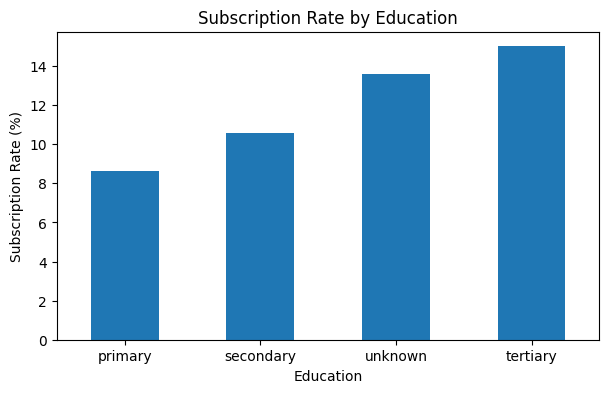

In [17]:
education_subscription = pd.crosstab(
    df['education'],
    df['y'],
    normalize='index'
) * 100

education_subscription['yes'].sort_values().plot(
    kind='bar',
    figsize=(7, 4)
)

plt.title('Subscription Rate by Education')
plt.xlabel('Education')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)
plt.show()

Subscription rates increase with education level, with tertiary-educated clients having the highest rate and primary-educated clients having the lowest. The unknown group also shows a relatively high subscription rate, so it is useful to retain it as a separate category.

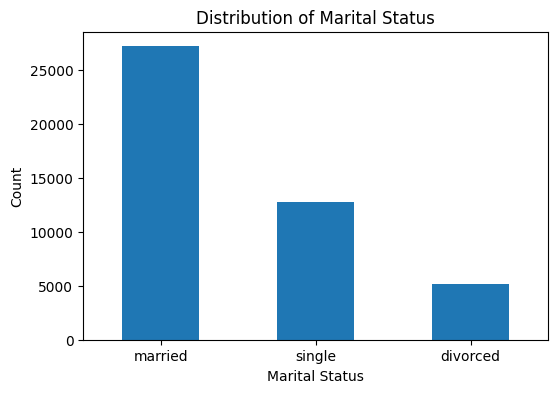

In [18]:
df['marital'].value_counts().plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title('Distribution of Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Most clients are married, followed by single and divorced clients. All three categories have a sufficient number of records, and there are no unknown or missing categories in this feature.

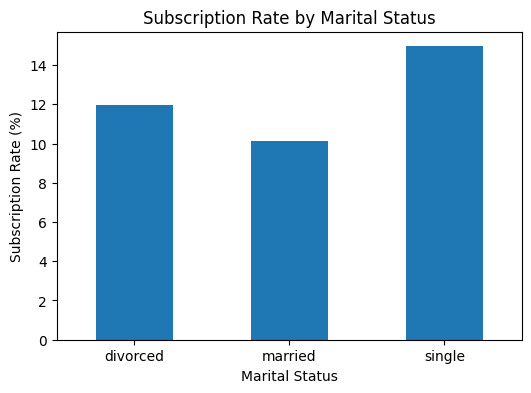

In [19]:
marital_subscription = pd.crosstab(
    df['marital'],
    df['y'],
    normalize='index'
) * 100

marital_subscription['yes'].plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title('Subscription Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)
plt.show()

Single clients have the highest subscription rate, followed by divorced and married clients. The differences suggest that marital status may be related to subscription behavior, although it may also be influenced by other factors such as age and job.


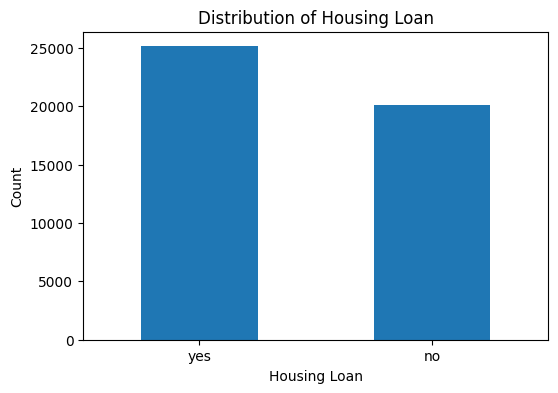

In [20]:
df['housing'].value_counts().plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title('Distribution of Housing Loan')
plt.xlabel('Housing Loan')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

The dataset is fairly balanced between clients with and without a housing loan, with slightly more clients having a housing loan. Both categories contain enough records for reliable comparison of their subscription rates.

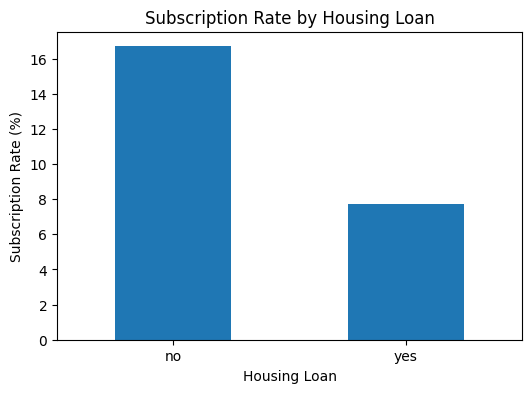

In [21]:
housing_subscription = pd.crosstab(
    df['housing'],
    df['y'],
    normalize='index'
) * 100

housing_subscription['yes'].plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title('Subscription Rate by Housing Loan')
plt.xlabel('Housing Loan')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)
plt.show()

Clients without a housing loan have a noticeably higher subscription rate than clients with a housing loan. This shows a strong association between housing loan status and subscription, although the relationship does not imply causation.

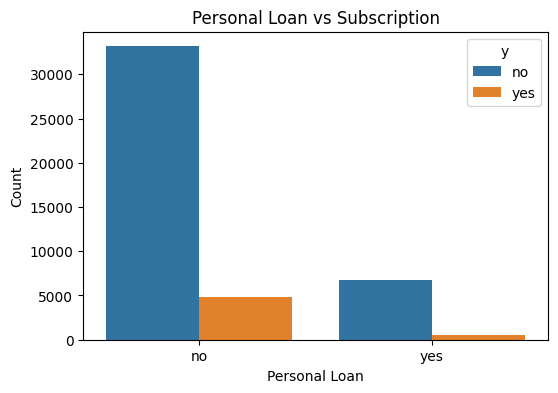

In [22]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='loan', hue='y')

plt.title('Personal Loan vs Subscription')
plt.xlabel('Personal Loan')
plt.ylabel('Count')
plt.show()

Clients without a personal loan have a higher subscription rate than those with a personal loan. The difference is noticeable, although it is smaller than the difference observed for housing loans.

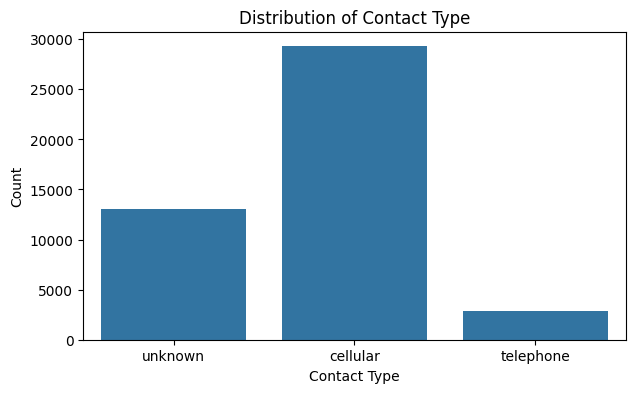

In [23]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x='contact')

plt.title('Distribution of Contact Type')
plt.xlabel('Contact Type')
plt.ylabel('Count')
plt.show()

Most clients were contacted through cellular communication, while telephone was used for a smaller portion of clients. A considerable 29% of records have an unknown contact type, so this category should be retained during preprocessing rather than removed.

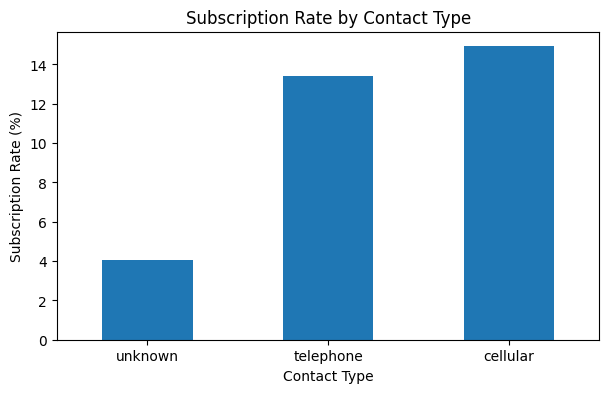

In [24]:
contact_subscription = pd.crosstab(
    df['contact'],
    df['y'],
    normalize='index'
) * 100

contact_subscription['yes'].sort_values().plot(
    kind='bar',
    figsize=(7, 4)
)

plt.title('Subscription Rate by Contact Type')
plt.xlabel('Contact Type')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)
plt.show()

Clients with a known contact type have much higher subscription rates than those with an unknown contact type. Since unknown represents a large portion of the dataset, it should be retained as a separate category during preprocessing

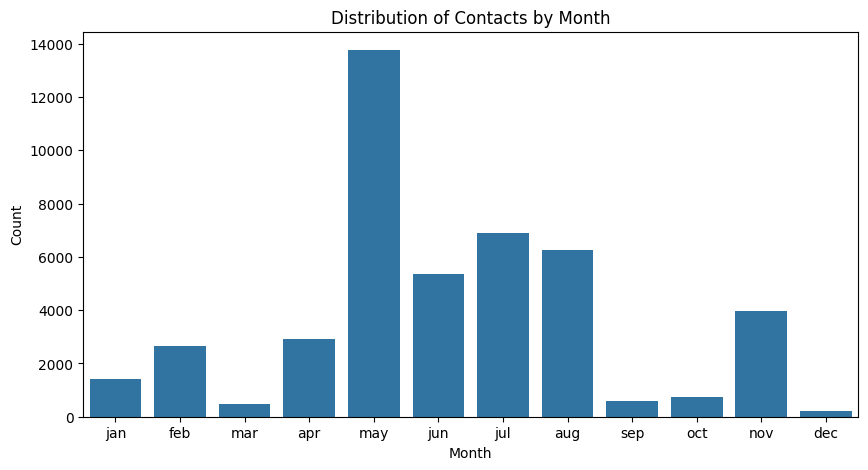

In [25]:
month_order = [
    'jan', 'feb', 'mar', 'apr', 'may', 'jun',
    'jul', 'aug', 'sep', 'oct', 'nov', 'dec'
]

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='month',
    order=month_order
)

plt.title('Distribution of Contacts by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

The number of client contacts varies considerably across months, with May having the highest number of contacts and several summer months also contributing a large share of the data. Some months have relatively few records, so their subscription rates should be interpreted carefully.

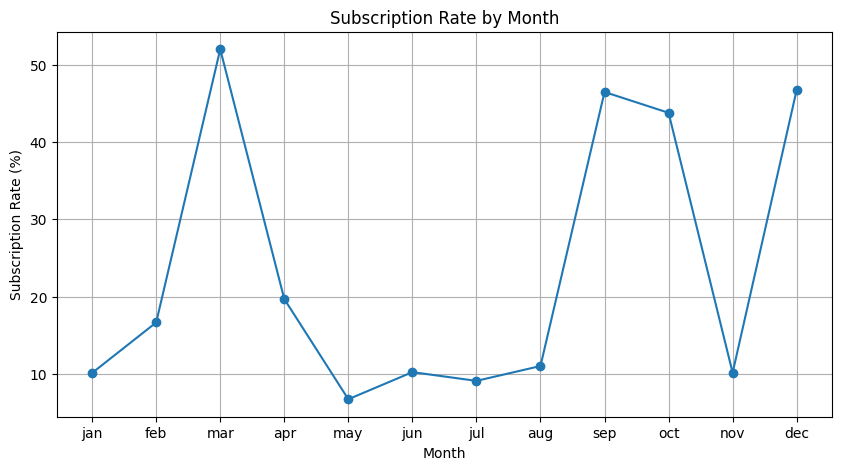

In [26]:
month_subscription = pd.crosstab(
    df['month'],
    df['y'],
    normalize='index'
) * 100

month_subscription = month_subscription.reindex(month_order)

plt.figure(figsize=(10, 5))

plt.plot(
    month_subscription.index,
    month_subscription['yes'],
    marker='o'
)

plt.title('Subscription Rate by Month')
plt.xlabel('Month')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)
plt.grid(True)

plt.show()

Subscription rates vary considerably across months, with the highest rates observed in the low-volume months and the lowest rate in May, which contains the largest number of contacts. This suggests that the month of contact may be strongly associated with subscription, although the high rates in low-volume months should be interpreted cautiously.

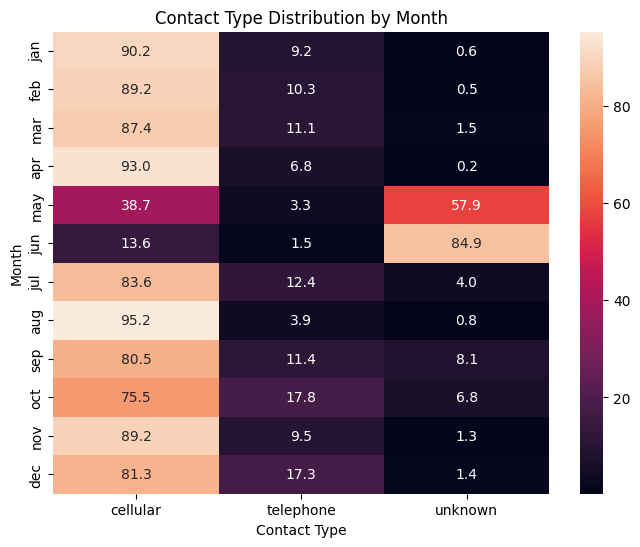

In [27]:
contact_month = pd.crosstab(
    df['month'],
    df['contact'],
    normalize='index'
) * 100

contact_month = contact_month.reindex(month_order)

plt.figure(figsize=(8, 6))

sns.heatmap(
    contact_month,
    annot=True,
    fmt='.1f'
)

plt.title('Contact Type Distribution by Month')
plt.xlabel('Contact Type')
plt.ylabel('Month')
plt.show()

The unknown contact category is highly concentrated in May and June, while cellular contact dominates most other months. This suggests that the unknown category is partly related to how contact information was recorded during specific campaign periods.

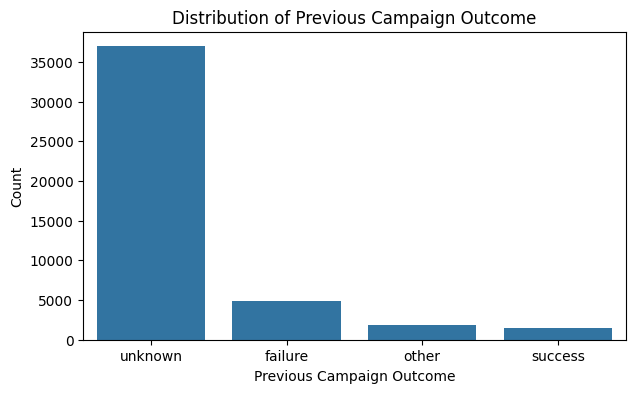

In [28]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x='poutcome')

plt.title('Distribution of Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Count')
plt.show()

Most clients have an unknown previous campaign outcome, indicating that they generally had no recorded previous campaign contact. Among clients with previous campaign history, failure is the most common outcome, while success is the smallest group.

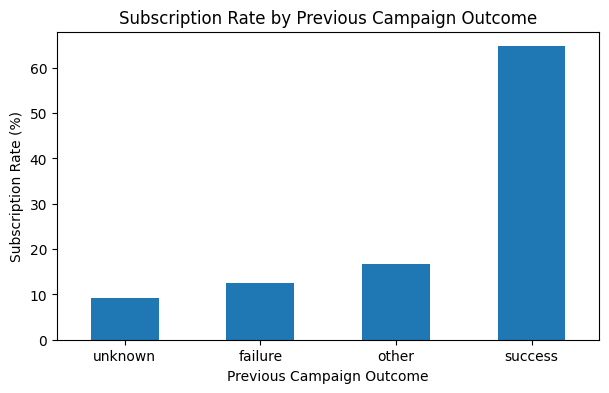

In [29]:
poutcome_subscription = pd.crosstab(
    df['poutcome'],
    df['y'],
    normalize='index'
) * 100

poutcome_subscription['yes'].sort_values().plot(
    kind='bar',
    figsize=(7, 4)
)

plt.title('Subscription Rate by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)
plt.show()

Previous campaign outcome shows a strong association with current subscription. Clients with a previous success have a much higher subscription rate than the other groups, while clients with unknown outcomes have a lower rate. This suggests that previous campaign history may be an important feature for predicting subscription.

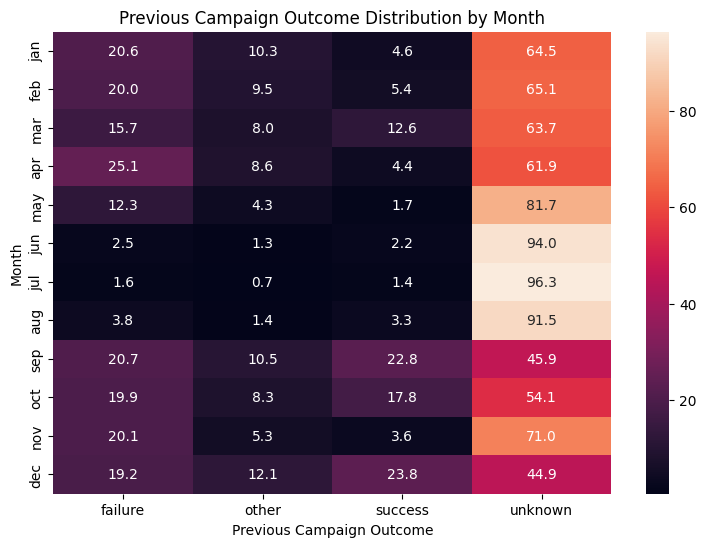

In [30]:
poutcome_month = pd.crosstab(
    df['month'],
    df['poutcome'],
    normalize='index'
) * 100

poutcome_month = poutcome_month.reindex(month_order)

plt.figure(figsize=(9, 6))
sns.heatmap(
    poutcome_month,
    annot=True,
    fmt='.1f'
)

plt.title('Previous Campaign Outcome Distribution by Month')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Month')
plt.show()

Previous campaign history varies considerably across months. September, October, and December have a much larger proportion of clients with previous campaign outcomes, while May to August are dominated by clients with no previous history. This suggests that both campaign timing and previous contact history may be associated with subscription behavior.

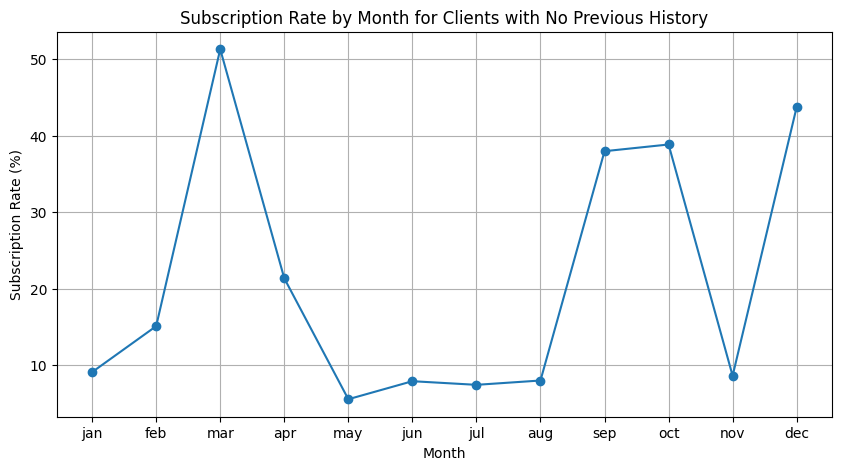

In [31]:
unknown_month = df[df['poutcome'] == 'unknown']

unknown_month_subscription = pd.crosstab(
    unknown_month['month'],
    unknown_month['y'],
    normalize='index'
) * 100

unknown_month_subscription = unknown_month_subscription.reindex(month_order)

plt.figure(figsize=(10, 5))
plt.plot(
    unknown_month_subscription.index,
    unknown_month_subscription['yes'],
    marker='o'
)

plt.title('Subscription Rate by Month for Clients with No Previous History')
plt.xlabel('Month')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

Even among clients with no previous campaign history, subscription rates vary substantially across months. March, December, October, and September have much higher rates than May to August, showing that the month of contact may contain important information about campaign behavior. However, the higher rates in low-volume months should be interpreted carefully because they contain fewer records.


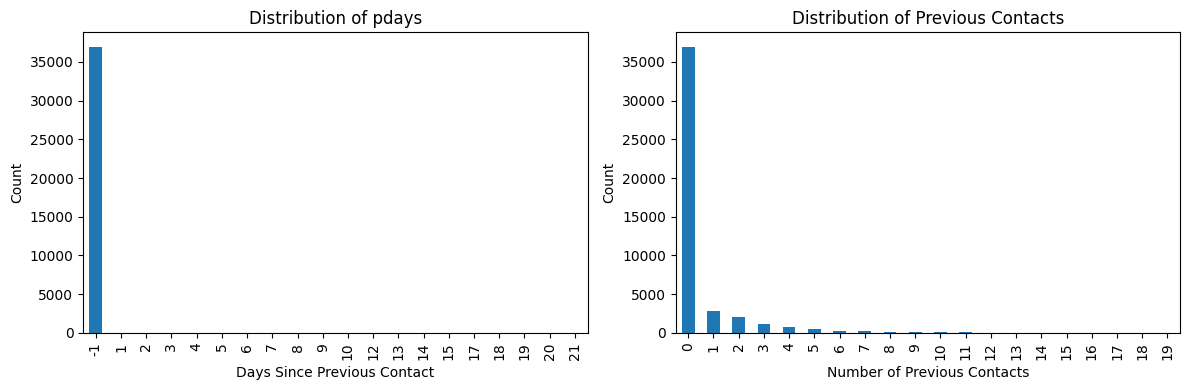

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['pdays'].value_counts().sort_index().head(20).plot(
    kind='bar',
    ax=axes[0]
)
axes[0].set_title('Distribution of pdays')
axes[0].set_xlabel('Days Since Previous Contact')
axes[0].set_ylabel('Count')

df['previous'].value_counts().sort_index().head(20).plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title('Distribution of Previous Contacts')
axes[1].set_xlabel('Number of Previous Contacts')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Most clients have no previous campaign history, with pdays = -1 and previous = 0 for about 82% of the records. The pdays = -1 value represents clients who were not contacted before, so it should not be treated as a normal numerical value or an outlier.

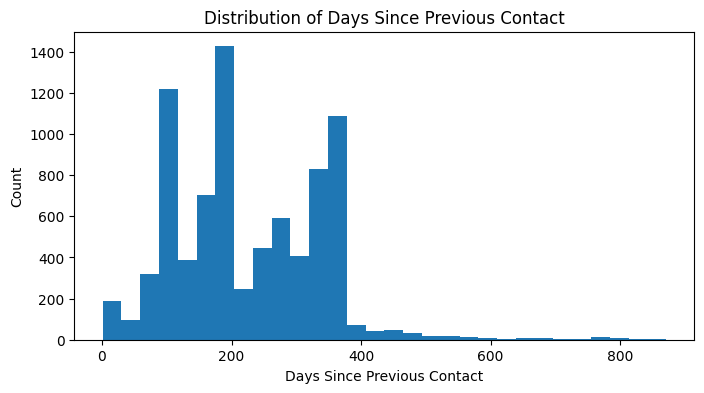

In [33]:
pdays_contacted = df[df['pdays'] > 0]['pdays']

plt.figure(figsize=(8, 4))
plt.hist(pdays_contacted, bins=30)

plt.title('Distribution of Days Since Previous Contact')
plt.xlabel('Days Since Previous Contact')
plt.ylabel('Count')
plt.show()

Among clients who were contacted previously, most contacts occurred within roughly one year, with several noticeable clusters in the distribution. A small number of clients were contacted much earlier, creating a long right tail. This shows that pdays is highly skewed and has a different pattern from a normally distributed numerical variable.

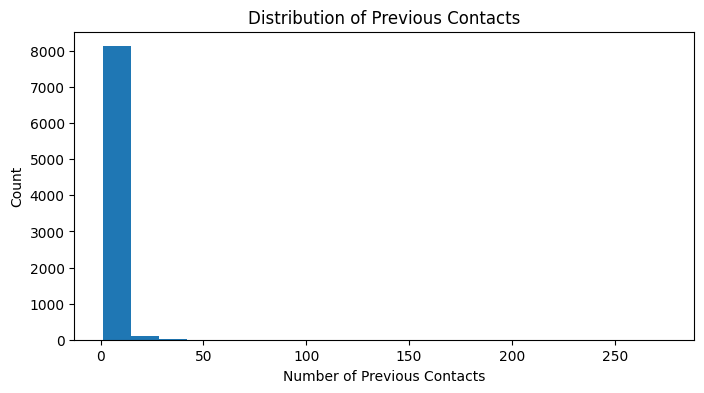

In [34]:
previous_contacted = df[df['previous'] > 0]['previous']

plt.figure(figsize=(8, 4))
plt.hist(previous_contacted, bins=20)

plt.title('Distribution of Previous Contacts')
plt.xlabel('Number of Previous Contacts')
plt.ylabel('Count')
plt.show()

The number of previous contacts is strongly right-skewed, with most previously contacted clients having only a small number of earlier contacts. A small number of clients have much higher values, creating a long right tail. These extreme values will be considered during preprocessing before model training.

In [35]:
df['previous'].max()

275

In [36]:
df.nlargest(10, 'previous')[['age', 'job', 'poutcome', 'previous', 'pdays', 'y']]

,age,job,poutcome,previous,pdays,y
29182,40,management,other,275,262,no
38326,46,blue-collar,other,58,353,yes
44089,37,technician,failure,55,776,yes
28886,31,management,failure,51,256,no
44822,27,blue-collar,other,41,778,no
42611,35,technician,other,40,270,no
28498,49,management,failure,38,248,no
37567,39,management,failure,38,261,no
26668,51,entrepreneur,other,37,112,no
42422,27,student,other,37,95,no


The previous feature is strongly right-skewed, with most clients having only a few previous contacts and a small number having much higher values. The maximum value is 275, which is an extreme observation but is present in the original data, so it will not be removed without further evidence. Its skewness will be considered during preprocessing and model development.

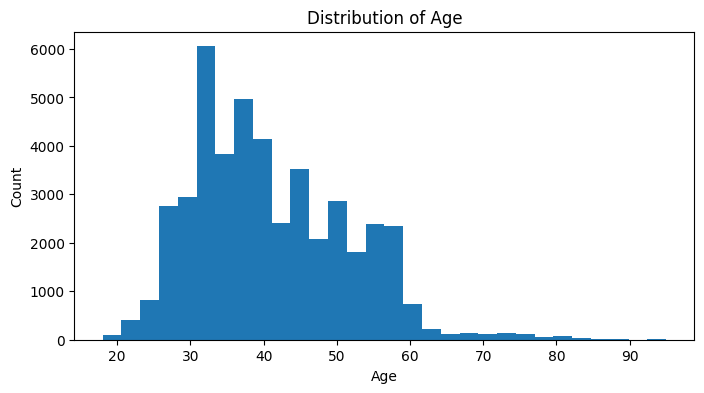

In [37]:
plt.figure(figsize=(8, 4))
plt.hist(df['age'], bins=30)

plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Most clients are between their late 20s and early 50s, with fewer clients at the younger and older extremes. The age distribution is slightly right-skewed, with a small number of older clients extending the range up to 95 years.

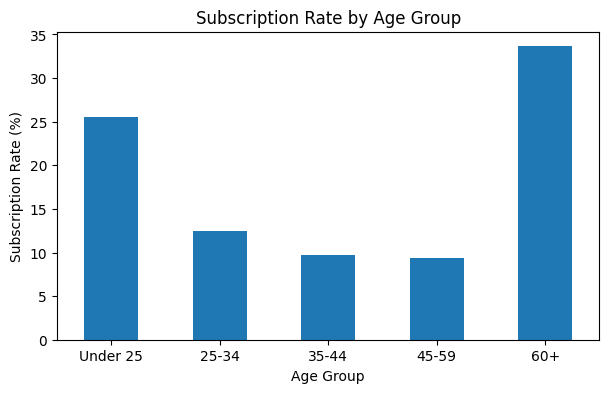

In [38]:
age_group = pd.cut(
    df['age'],
    bins=[17, 24, 34, 44, 59, 100],
    labels=['Under 25', '25-34', '35-44', '45-59', '60+']
)

age_subscription = pd.crosstab(
    age_group,
    df['y'],
    normalize='index'
) * 100

age_subscription['yes'].plot(
    kind='bar',
    figsize=(7, 4)
)

plt.title('Subscription Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)
plt.show()

Subscription rates differ across age groups, with the highest rates among clients under 25 and those aged 60 or above. The middle age groups have lower subscription rates, suggesting that age may have a non-linear relationship with subscription behavior.

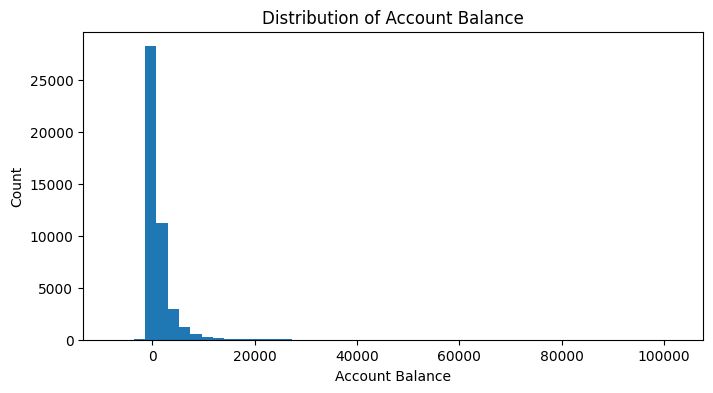

In [39]:
plt.figure(figsize=(8, 4))
plt.hist(df['balance'], bins=50)

plt.title('Distribution of Account Balance')
plt.xlabel('Account Balance')
plt.ylabel('Count')
plt.show()

Account balance is highly right-skewed, with most clients having relatively low balances and a small number having very large balances. Negative balances are also present, representing overdrawn accounts. The wide range suggests that the feature should be considered carefully during preprocessing and model development.

In [40]:
df.nlargest(10, 'balance')[['age', 'job', 'balance', 'housing', 'loan', 'y']]

,age,job,balance,housing,loan,y
39989,51,management,102127,no,no,no
26227,59,management,98417,no,no,no
42558,84,retired,81204,no,no,yes
43393,84,retired,81204,no,no,yes
41693,60,retired,71188,no,no,no
19785,56,management,66721,no,no,no
21192,52,blue-collar,66653,no,no,no
19420,59,admin.,64343,no,no,no
41374,32,entrepreneur,59649,no,no,no
12926,56,blue-collar,58932,no,no,no


The highest account balances belong to clients from different age and job groups, suggesting that the extreme values are not limited to a single category. Since these values appear to be valid observations, they will be retained and handled appropriately during preprocessing rather than removed as errors.

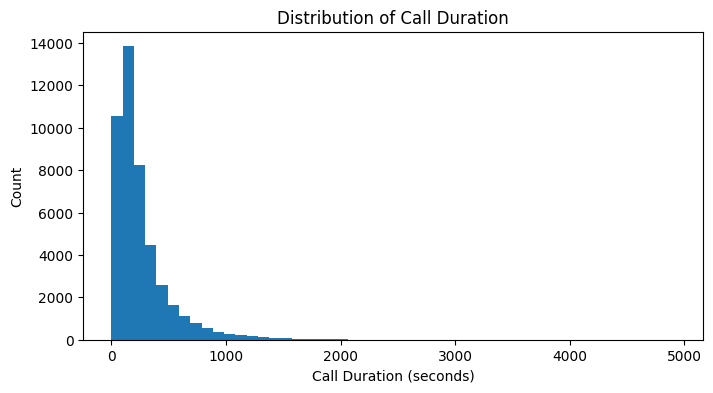

In [41]:
plt.figure(figsize=(8, 4))
plt.hist(df['duration'], bins=50)

plt.title('Distribution of Call Duration')
plt.xlabel('Call Duration (seconds)')
plt.ylabel('Count')
plt.show()

Call duration is right-skewed, with most calls lasting for a few minutes and a small number of very long calls creating a long right tail. The wide range indicates substantial variation in call length. Since duration is only known after the current call ends, its use will need to be considered carefully during model development.

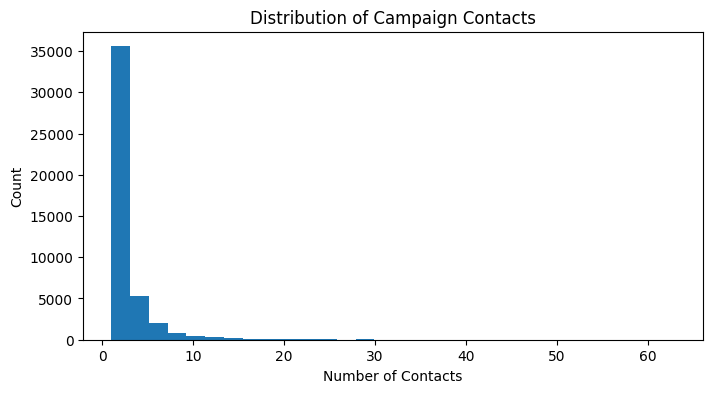

In [42]:
plt.figure(figsize=(8, 4))
plt.hist(df['campaign'], bins=30)

plt.title('Distribution of Campaign Contacts')
plt.xlabel('Number of Contacts')
plt.ylabel('Count')
plt.show()

The number of contacts during the current campaign is heavily right-skewed, with most clients contacted only a few times and a small number contacted many times. The long right tail shows that repeated contacts are uncommon, so this feature may need careful handling during preprocessing.

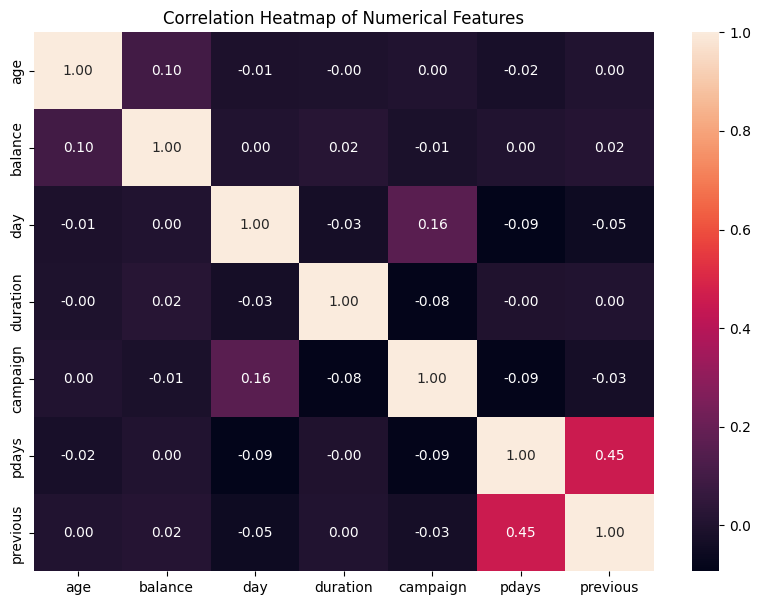

In [43]:
numeric_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

The numerical features show generally weak correlations with each other, indicating that there is no major multicollinearity problem. The strongest relationship is between pdays and previous with a correlation of about 0.45, which is expected because both describe previous campaign activity.

In [44]:
df['y'] = df['y'].map({'no': 0, 'yes': 1})

df['y'].value_counts()

,count
y,
0,39922
1,5289


In [46]:
X = df.drop('y', axis=1)
y = df['y']

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (36168, 16)
Testing set: (9043, 16)


In [48]:
numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [49]:
print("Number of numerical features:", len(numeric_cols))
print("Number of categorical features:", len(categorical_cols))

Number of numerical features: 7
Number of categorical features: 9


In [50]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [51]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (36168, 51)
Testing shape: (9043, 51)


In [52]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [53]:
y_pred = logistic_model.predict(X_test_processed)

print(y_pred[:10])

[0 0 0 0 0 0 0 1 0 0]


In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.901249585314608
Precision: 0.6444833625218914
Recall   : 0.34782608695652173
F1 Score : 0.4518109269490485


In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



The baseline Logistic Regression model achieved 90.12% accuracy, but its recall for the yes class was only 34.78%. This indicates that the model correctly identifies many non-subscribers but misses a considerable number of clients who actually subscribe, so accuracy alone is not sufficient for evaluating this imbalanced dataset.

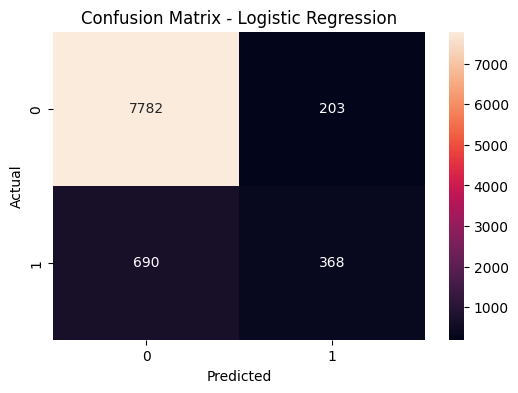

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [57]:
from sklearn.metrics import roc_auc_score

y_prob = logistic_model.predict_proba(X_test_processed)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9055740146044154


In [58]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob)

print("PR-AUC:", pr_auc)

PR-AUC: 0.5451315654132785


The Logistic Regression model achieved a ROC-AUC of 0.906, indicating good overall class-separation ability across different decision thresholds. The PR-AUC of 0.545 shows that identifying the minority yes class remains more challenging, so precision and recall should be considered alongside accuracy and ROC-AUC.

In [59]:
X_no_duration = X.drop('duration', axis=1)

X_train_nd, X_test_nd, y_train_nd, y_test_nd = train_test_split(
    X_no_duration,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [60]:
numeric_cols_nd = X_train_nd.select_dtypes(include='number').columns.tolist()
categorical_cols_nd = X_train_nd.select_dtypes(include='object').columns.tolist()

In [61]:
preprocessor_nd = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols_nd),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_nd)
    ]
)

X_train_nd_processed = preprocessor_nd.fit_transform(X_train_nd)
X_test_nd_processed = preprocessor_nd.transform(X_test_nd)

print("Training shape:", X_train_nd_processed.shape)
print("Testing shape:", X_test_nd_processed.shape)

Training shape: (36168, 50)
Testing shape: (9043, 50)


In [62]:
logistic_model_nd = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model_nd.fit(X_train_nd_processed, y_train_nd)

y_pred_nd = logistic_model_nd.predict(X_test_nd_processed)

In [63]:
accuracy_nd = accuracy_score(y_test_nd, y_pred_nd)
precision_nd = precision_score(y_test_nd, y_pred_nd)
recall_nd = recall_score(y_test_nd, y_pred_nd)
f1_nd = f1_score(y_test_nd, y_pred_nd)

print("Accuracy :", accuracy_nd)
print("Precision:", precision_nd)
print("Recall   :", recall_nd)
print("F1 Score :", f1_nd)

Accuracy : 0.8932876257879022
Precision: 0.6631578947368421
Recall   : 0.1786389413988658
F1 Score : 0.28145941921072226


In [64]:
y_prob_nd = logistic_model_nd.predict_proba(X_test_nd_processed)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test_nd, y_prob_nd))
print("PR-AUC :", average_precision_score(y_test_nd, y_prob_nd))

ROC-AUC: 0.7717487775401183
PR-AUC : 0.41108132835312927


Removing duration reduced the model's performance, with ROC-AUC decreasing from 90.56% to 77.17% and F1-score decreasing from 45.18% to 28.15%. This shows that duration contains substantial information about the final subscription outcome, but because it is measured during the current call, its use should depend on the intended prediction scenario.

In [65]:
balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

balanced_model.fit(X_train_processed, y_train)

y_pred_balanced = balanced_model.predict(X_test_processed)

In [66]:
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)

print("Accuracy :", accuracy_balanced)
print("Precision:", precision_balanced)
print("Recall   :", recall_balanced)
print("F1 Score :", f1_balanced)

Accuracy : 0.8457370341700763
Precision: 0.41824357108199905
Recall   : 0.8147448015122873
F1 Score : 0.5527412632253927


In [67]:
y_prob_balanced = balanced_model.predict_proba(X_test_processed)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_balanced))
print("PR-AUC :", average_precision_score(y_test, y_prob_balanced))

ROC-AUC: 0.9079218714674134
PR-AUC : 0.5376357629157977


Using class_weight='balanced' increased recall for the yes class from 34.78% to 81.47% and improved F1-score from 45.18% to 55.27%. However, accuracy decreased from 90.12% to 84.57% and precision decreased from 64.45% to 41.82%, showing the trade-off between identifying more subscribers and producing more false positives.

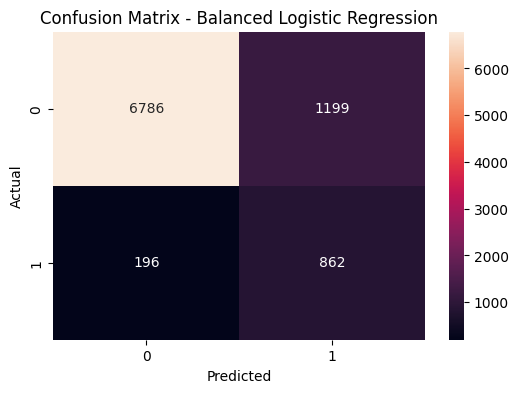

In [68]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_balanced,
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix - Balanced Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The balanced Logistic Regression model reduced false negatives from 690 to 196, identifying many more actual subscribers than the baseline model. However, false positives increased from 203 to 1,199, showing the trade-off between improving recall and reducing incorrect positive predictions.


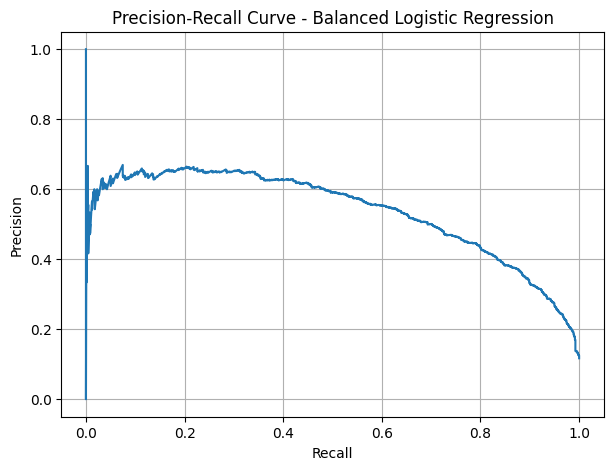

In [69]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_balanced
)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)

plt.title('Precision-Recall Curve - Balanced Logistic Regression')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

The Precision-Recall curve shows a clear trade-off between precision and recall, with precision decreasing as more positive cases are identified. The baseline and balanced Logistic Regression models follow a similar curve, indicating that class weighting mainly changes the decision point rather than substantially improving the model's ability to rank subscribers.


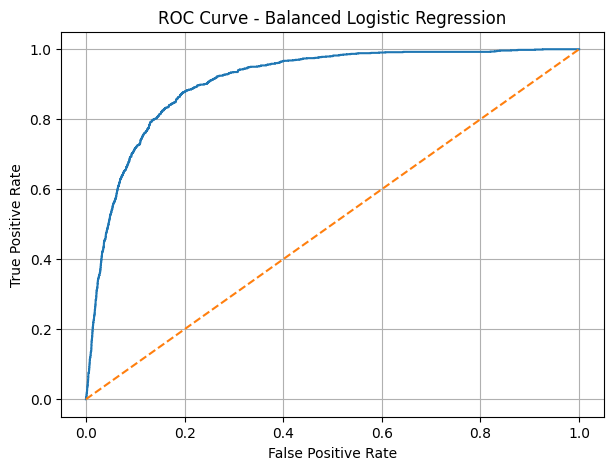

In [70]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_balanced
)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve - Balanced Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()

The balanced Logistic Regression model achieved a ROC-AUC of 0.908, indicating good ability to distinguish between subscribers and non-subscribers across different thresholds. However, because duration is included and is measured during the current call, this result should not be treated as a realistic pre-call prediction performance.

In [71]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [72]:
y_pred_rf = rf_model.predict(X_test_processed)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.9044564856795311
Precision: 0.6506211180124224
Recall   : 0.3960302457466919
F1 Score : 0.49236192714453586


The Random Forest model achieved 90.45% accuracy, 65.06% precision, 39.60% recall, and an F1-score of 49.24%. Compared with the baseline Logistic Regression, it shows modest improvement across all four metrics, particularly in recall and F1-score.

In [73]:
y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC :", average_precision_score(y_test, y_prob_rf))

ROC-AUC: 0.926285639543899
PR-AUC : 0.6103755883213137


The Random Forest model achieved 90.45% accuracy, 65.06% precision, 39.60% recall, and an F1-score of 49.24%, with a ROC-AUC of 92.63% and PR-AUC of 61.04%. Compared with the baseline Logistic Regression, Random Forest provides better overall performance and improves its ability to identify the minority yes class, although recall remains relatively low.

[[7760  225]
 [ 639  419]]


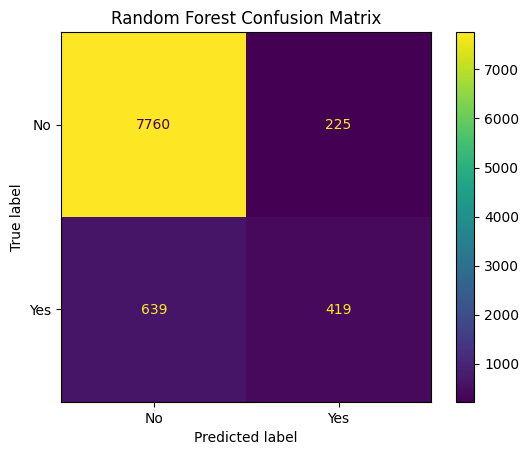

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['No', 'Yes']
)

disp.plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

The Random Forest model correctly identified 419 subscribers and missed 639 actual subscribers, while producing 225 false positive predictions. Compared with the baseline Logistic Regression, it identifies more actual subscribers and reduces false negatives, but still misses a considerable number of positive cases.

In [75]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,num__duration,0.266352
1,num__balance,0.093719
0,num__age,0.090248
2,num__day,0.080616
49,cat__poutcome_success,0.044543
4,num__campaign,0.038455
5,num__pdays,0.037765
6,num__previous,0.020399
28,cat__housing_no,0.013628
29,cat__housing_yes,0.012654


The Random Forest feature importance shows that duration is the most influential feature, followed by balance, age, and day. poutcome_success is the most important individual categorical feature, which is consistent with the high subscription rate observed for clients with a previous successful campaign outcome. Since duration is measured after the current call, its importance should be considered carefully when defining the prediction scenario.

In [76]:
X_no_duration = X.drop('duration', axis=1)

X_train_nd, X_test_nd, y_train_nd, y_test_nd = train_test_split(
    X_no_duration,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [77]:
numeric_cols_nd = X_train_nd.select_dtypes(include='number').columns.tolist()
categorical_cols_nd = X_train_nd.select_dtypes(include='object').columns.tolist()

preprocessor_nd = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols_nd),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_nd)
    ]
)

X_train_nd_processed = preprocessor_nd.fit_transform(X_train_nd)
X_test_nd_processed = preprocessor_nd.transform(X_test_nd)

In [78]:
rf_model_nd = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model_nd.fit(X_train_nd_processed, y_train_nd)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [79]:
y_pred_rf_nd = rf_model_nd.predict(X_test_nd_processed)

print("Accuracy :", accuracy_score(y_test_nd, y_pred_rf_nd))
print("Precision:", precision_score(y_test_nd, y_pred_rf_nd))
print("Recall   :", recall_score(y_test_nd, y_pred_rf_nd))
print("F1 Score :", f1_score(y_test_nd, y_pred_rf_nd))

Accuracy : 0.895388698440783
Precision: 0.6372549019607843
Recall   : 0.24574669187145556
F1 Score : 0.35470668485675305


In [80]:
y_prob_rf_nd = rf_model_nd.predict_proba(X_test_nd_processed)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test_nd, y_prob_rf_nd))
print("PR-AUC :", average_precision_score(y_test_nd, y_prob_rf_nd))

ROC-AUC: 0.7887879921355377
PR-AUC : 0.428370429120677


Removing duration reduced Random Forest performance, with ROC-AUC decreasing from 92.63% to 78.88% and F1-score decreasing from 49.24% to 35.47%. This confirms that duration contains substantial information about the subscription outcome, but because it is measured during the current call, the model without duration is more suitable for a pre-call prediction scenario.

In [81]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Logistic Regression (No Duration)',
        'Balanced Logistic Regression',
        'Random Forest',
        'Random Forest (No Duration)'
    ],
    'Accuracy': [
        0.9012, 0.8933, 0.8457, 0.9045, 0.8954
    ],
    'Precision': [
        0.6445, 0.6632, 0.4182, 0.6506, 0.6373
    ],
    'Recall': [
        0.3478, 0.1786, 0.8147, 0.3960, 0.2457
    ],
    'F1 Score': [
        0.4518, 0.2815, 0.5527, 0.4924, 0.3547
    ],
    'ROC-AUC': [
        0.9056, 0.7717, 0.9079, 0.9263, 0.7888
    ],
    'PR-AUC': [
        0.5451, 0.4111, 0.5376, 0.6104, 0.4284
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9012,0.6445,0.3478,0.4518,0.9056,0.5451
1,Logistic Regression (No Duration),0.8933,0.6632,0.1786,0.2815,0.7717,0.4111
2,Balanced Logistic Regression,0.8457,0.4182,0.8147,0.5527,0.9079,0.5376
3,Random Forest,0.9045,0.6506,0.3960,0.4924,0.9263,0.6104
4,Random Forest (No Duration),0.8954,0.6373,0.2457,0.3547,0.7888,0.4284


The model comparison shows that Random Forest with duration achieved the highest accuracy, ROC-AUC, and PR-AUC, while Balanced Logistic Regression achieved the highest recall and F1-score. Removing duration substantially reduced performance for both models, highlighting its strong predictive information. However, because duration is available only after the current call, the appropriate model depends on whether prediction is required before or during the campaign.

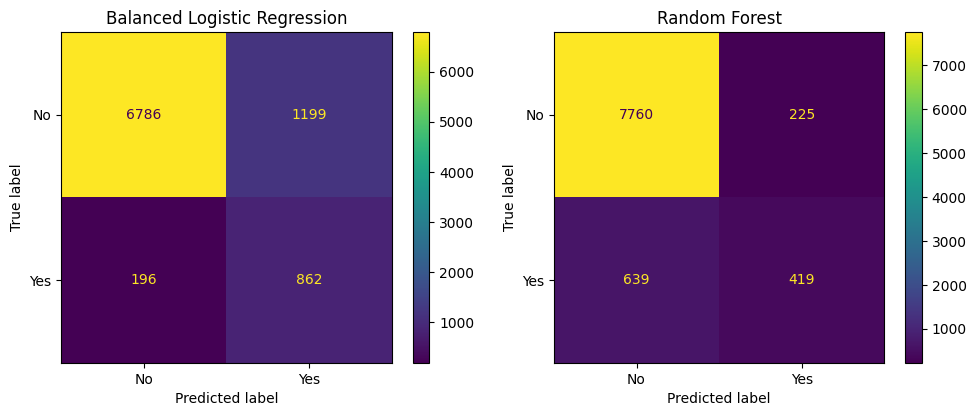

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_balanced,
    display_labels=['No', 'Yes'],
    ax=axes[0]
)
axes[0].set_title('Balanced Logistic Regression')

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No', 'Yes'],
    ax=axes[1]
)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()

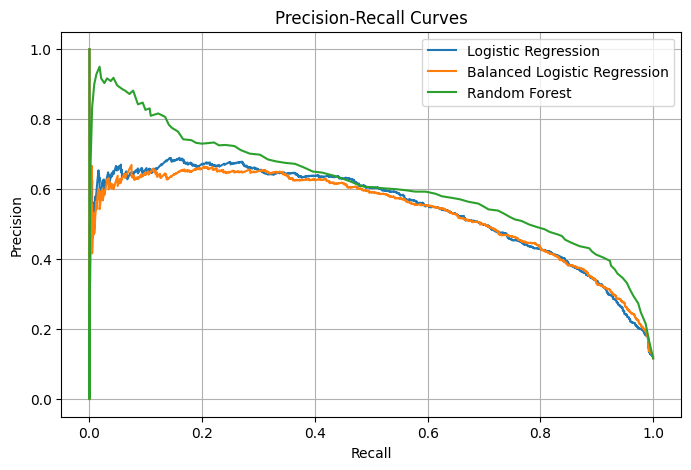

In [85]:
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob)
precision_bal, recall_bal, _ = precision_recall_curve(y_test, y_prob_balanced)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 5))

plt.plot(
    recall_lr,
    precision_lr,
    label='Logistic Regression'
)

plt.plot(
    recall_bal,
    precision_bal,
    label='Balanced Logistic Regression'
)

plt.plot(
    recall_rf,
    precision_rf,
    label='Random Forest'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid(True)
plt.show()

The Precision-Recall curves show that the two Logistic Regression models have very similar ranking performance, while Random Forest generally achieves higher precision at the same recall levels. This indicates that Random Forest can rank likely subscribers somewhat more effectively, particularly when focusing on a smaller group of high-confidence predictions. However, this comparison includes duration, which is only known after the current call, so the result should be interpreted according to the intended prediction scenario.

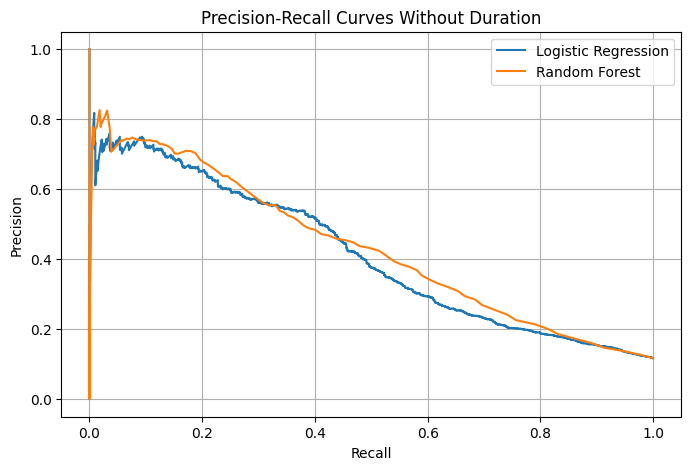

In [86]:
precision_lr_nd, recall_lr_nd, _ = precision_recall_curve(
    y_test_nd, y_prob_nd
)

precision_rf_nd, recall_rf_nd, _ = precision_recall_curve(
    y_test_nd, y_prob_rf_nd
)

plt.figure(figsize=(8, 5))

plt.plot(
    recall_lr_nd,
    precision_lr_nd,
    label='Logistic Regression'
)

plt.plot(
    recall_rf_nd,
    precision_rf_nd,
    label='Random Forest'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves Without Duration')
plt.legend()
plt.grid(True)
plt.show()

Excluding duration, which is unavailable before the current call, substantially reduces the precision-recall performance of both models. Random Forest maintains a modest advantage over Logistic Regression at moderate recall levels, but the difference becomes small at higher recall. Therefore, the no-duration results provide a more realistic estimate of performance for pre-call customer targeting.

In [87]:
import joblib

joblib.dump(rf_model_nd, 'bank_marketing_rf.pkl')
joblib.dump(preprocessor_nd, 'bank_marketing_preprocessor.pkl')

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.
